# Feature Engineering: Pair Chemistry

Признаки, характеризующие **состав пары**, а не индивидуальную силу игроков:

- `pair_matches_together` - сколько матчей пара отыграла вместе до текущего
- `pair_wins_together` - сколько из них выиграла
- `pair_winrate` - `pair_wins_together / pair_matches_together`
- `pair_winrate_last5` - win rate в последних 5 совместных матчах

Результат: `data/features/pair_chemistry.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict, deque
import matplotlib.pyplot as plt

PROCESSED = Path("../../data/processed")
FEATURES = Path("../../data/features")

df = pd.read_csv(PROCESSED / "matches.csv", parse_dates=["played_at"])
df = df.sort_values("played_at").reset_index(drop=True)
print(f"Матчей: {len(df)}")

Матчей: 2549


In [2]:
def _pair_key(a, b):
    return (int(min(a, b)), int(max(a, b)))


def compute_pair_chemistry(df, recent_window=5):
    df = df.sort_values("played_at").reset_index(drop=True)
    n_together = defaultdict(int)
    n_wins = defaultdict(int)
    recent_wins = defaultdict(lambda: deque(maxlen=recent_window))

    records = []

    for _, row in df.iterrows():
        k1 = _pair_key(row["player_id_1"], row["player_id_2"])
        k2 = _pair_key(row["player_id_3"], row["player_id_4"])

        rec = {"match_id": row["match_id"]}
        for prefix, k in [("team1", k1), ("team2", k2)]:
            n = n_together[k]
            w = n_wins[k]
            rec[f"{prefix}_pair_matches_together"] = n
            rec[f"{prefix}_pair_wins_together"] = w
            rec[f"{prefix}_pair_winrate"] = (w / n) if n > 0 else np.nan
            rw = recent_wins[k]
            rec[f"{prefix}_pair_winrate_last{recent_window}"] = (sum(rw) / len(rw)) if rw else np.nan
        records.append(rec)

        t1_win = 1 if row["winner"] == "team_1" else 0
        n_together[k1] += 1
        n_together[k2] += 1
        n_wins[k1] += t1_win
        n_wins[k2] += 1 - t1_win
        recent_wins[k1].append(t1_win)
        recent_wins[k2].append(1 - t1_win)

    return pd.DataFrame(records)

In [3]:
pair_chem = compute_pair_chemistry(df, recent_window=5)
print(pair_chem.describe())

          match_id  team1_pair_matches_together  team1_pair_wins_together  \
count  2549.000000                  2549.000000               2549.000000   
mean   2419.975284                    19.621420                 15.169478   
std    2176.372145                    37.990991                 34.871950   
min      34.000000                     0.000000                  0.000000   
25%     738.000000                     2.000000                  1.000000   
50%    1463.000000                     6.000000                  4.000000   
75%    3820.000000                    18.000000                 10.000000   
max    7478.000000                   227.000000                210.000000   

       team1_pair_winrate  team1_pair_is_new  team1_pair_winrate_last5  \
count         2178.000000        2549.000000               2178.000000   
mean             0.622363           0.422126                  0.600497   
std              0.253076           0.493995                  0.276820   
min       

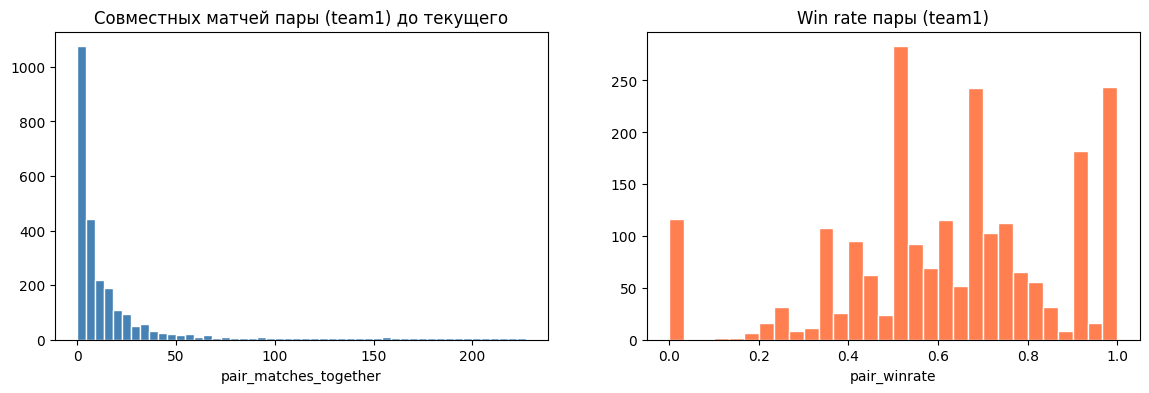

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(pair_chem["team1_pair_matches_together"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Совместных матчей пары (team1) до текущего")
axes[0].set_xlabel("pair_matches_together")

wr = pair_chem["team1_pair_winrate"].dropna()
axes[1].hist(wr, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Win rate пары (team1)")
axes[1].set_xlabel("pair_winrate")
plt.show()

In [6]:
out_path = FEATURES / "pair_chemistry.csv"
pair_chem.to_csv(out_path, index=False)